In [1]:
# ============================================================
# EXERCISE 7 - UNCERTAINTY QUANTIFICATION
# CELL 1 - SETUP
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("EXERCISE 7 - UNCERTAINTY QUANTIFICATION")
print("=" * 70)

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\n" + "-" * 70)
print("DEVICE")
print("-" * 70)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("GPU: Not available")


# ============================================================
# PATH CONFIGURATION
# ============================================================

BASE_PATH = r"E:\ML_Safety"

TRAIN_DIR = os.path.join(
    BASE_PATH,
    "train"
)

TEST_DIR = os.path.join(
    BASE_PATH,
    "test"
)

FOG_DIR = os.path.join(
    BASE_PATH,
    "test-fog"
)

NIGHT_DIR = os.path.join(
    BASE_PATH,
    "test-night"
)

TOWN_DIR = os.path.join(
    BASE_PATH,
    "test-town-01"
)

MODEL_DIR = os.path.join(
    BASE_PATH,
    "model_outputs"
)

OUTPUT_DIR = os.path.join(
    BASE_PATH,
    "uncertainty_results"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


print("\n" + "-" * 70)
print("PATH CONFIGURATION")
print("-" * 70)

print("Base path       :", BASE_PATH)
print("Train directory :", TRAIN_DIR)
print("Test directory  :", TEST_DIR)
print("Fog directory   :", FOG_DIR)
print("Night directory :", NIGHT_DIR)
print("Town directory  :", TOWN_DIR)
print("Model directory :", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)


# ============================================================
# DIRECTORY CHECK
# ============================================================

print("\n" + "-" * 70)
print("DIRECTORY CHECK")
print("-" * 70)

paths_to_check = {
    "Train": TRAIN_DIR,
    "Test": TEST_DIR,
    "Fog": FOG_DIR,
    "Night": NIGHT_DIR,
    "Town": TOWN_DIR,
    "Models": MODEL_DIR
}

for name, path in paths_to_check.items():

    status = "EXISTS" if os.path.exists(path) else "MISSING"

    print(
        f"{name:<10}: {status} -> {path}"
    )


# ============================================================
# IMAGE TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize(
        (224, 224)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

print("\n" + "-" * 70)
print("IMAGE TRANSFORM")
print("-" * 70)

print(transform)


# ============================================================
# MODEL PATHS
# ============================================================

MODEL_PATHS = {

    "Pedestrian": os.path.join(
        MODEL_DIR,
        "best_pedestrian.pth"
    ),

    "Traffic Light": os.path.join(
        MODEL_DIR,
        "best_traffic_light.pth"
    ),

    "Vehicle": os.path.join(
        MODEL_DIR,
        "best_vehicle.pth"
    )
}


print("\n" + "-" * 70)
print("MODEL FILE CHECK")
print("-" * 70)

for model_name, model_path in MODEL_PATHS.items():

    print(
        f"{model_name:<15}: "
        f"{os.path.exists(model_path)} -> "
        f"{model_path}"
    )


print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

EXERCISE 7 - UNCERTAINTY QUANTIFICATION

----------------------------------------------------------------------
DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
CUDA version: 12.1

----------------------------------------------------------------------
PATH CONFIGURATION
----------------------------------------------------------------------
Base path       : E:\ML_Safety
Train directory : E:\ML_Safety\train
Test directory  : E:\ML_Safety\test
Fog directory   : E:\ML_Safety\test-fog
Night directory : E:\ML_Safety\test-night
Town directory  : E:\ML_Safety\test-town-01
Model directory : E:\ML_Safety\model_outputs
Output directory: E:\ML_Safety\uncertainty_results

----------------------------------------------------------------------
DIRECTORY CHECK
----------------------------------------------------------------------
Train     : EXISTS -> E:\ML_Safety\train
Test      : EXISTS -> E:\ML_Safety\test
Fog    

In [2]:
# ============================================================
# EXERCISE 7 - UNCERTAINTY QUANTIFICATION
# CELL 2 - LOADING CARLA MODELS
# ============================================================

print("=" * 70)
print("EXERCISE 7 - LOADING CARLA MODELS")
print("=" * 70)


# ============================================================
# MODEL CREATION FUNCTION
# ============================================================

def create_carla_model(num_classes=2):

    model = models.resnet18(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    return model


# ============================================================
# MODEL LOADING FUNCTION
# ============================================================

def load_carla_model(
    model_path,
    model_name
):

    print("\n" + "-" * 60)
    print(f"Loading {model_name}...")
    print("-" * 60)

    model = create_carla_model(
        num_classes=2
    )

    checkpoint = torch.load(
        model_path,
        map_location=device,
        weights_only=False
    )

    print(
        "Checkpoint type:",
        type(checkpoint)
    )

    # --------------------------------------------------------
    # Handle the checkpoint format used by our CARLA models
    # --------------------------------------------------------

    if isinstance(checkpoint, dict):

        if "model_state_dict" in checkpoint:

            print(
                "Using checkpoint['model_state_dict']"
            )

            state_dict = checkpoint[
                "model_state_dict"
            ]

        elif "state_dict" in checkpoint:

            print(
                "Using checkpoint['state_dict']"
            )

            state_dict = checkpoint[
                "state_dict"
            ]

        else:

            print(
                "Using checkpoint directly as state_dict"
            )

            state_dict = checkpoint

    else:

        state_dict = checkpoint


    # --------------------------------------------------------
    # Remove DataParallel prefix if present
    # --------------------------------------------------------

    cleaned_state_dict = {}

    for key, value in state_dict.items():

        if key.startswith("module."):

            new_key = key[
                len("module.") :
            ]

        else:

            new_key = key

        cleaned_state_dict[
            new_key
        ] = value


    # --------------------------------------------------------
    # Load weights
    # --------------------------------------------------------

    model.load_state_dict(
        cleaned_state_dict,
        strict=True
    )

    model = model.to(device)

    model.eval()


    # --------------------------------------------------------
    # Verification
    # --------------------------------------------------------

    print(
        "Loaded successfully."
    )

    print(
        "Device:",
        next(model.parameters()).device
    )

    print(
        "Evaluation mode:",
        not model.training
    )

    print(
        "Trainable parameters:",
        sum(
            p.numel()
            for p in model.parameters()
        )
    )

    return model


# ============================================================
# LOAD ALL THREE MODELS
# ============================================================

models_for_uncertainty = {}

for model_name, model_path in MODEL_PATHS.items():

    models_for_uncertainty[
        model_name
    ] = load_carla_model(
        model_path,
        model_name
    )


# ============================================================
# MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

for model_name, model in models_for_uncertainty.items():

    parameter_count = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        f"{model_name:<15} | "
        f"Device: {next(model.parameters()).device} | "
        f"Parameters: {parameter_count:,}"
    )


print("\n" + "=" * 70)
print("ALL CARLA MODELS LOADED SUCCESSFULLY")
print("=" * 70)

print("\nCELL 2 COMPLETE")
print("=" * 70)

EXERCISE 7 - LOADING CARLA MODELS

------------------------------------------------------------
Loading Pedestrian...
------------------------------------------------------------
Checkpoint type: <class 'dict'>
Using checkpoint['model_state_dict']
Loaded successfully.
Device: cuda:0
Evaluation mode: True
Trainable parameters: 11177538

------------------------------------------------------------
Loading Traffic Light...
------------------------------------------------------------
Checkpoint type: <class 'dict'>
Using checkpoint['model_state_dict']
Loaded successfully.
Device: cuda:0
Evaluation mode: True
Trainable parameters: 11177538

------------------------------------------------------------
Loading Vehicle...
------------------------------------------------------------
Checkpoint type: <class 'dict'>
Using checkpoint['model_state_dict']
Loaded successfully.
Device: cuda:0
Evaluation mode: True
Trainable parameters: 11177538

MODEL SUMMARY
Pedestrian      | Device: cuda:0 | Paramet

In [3]:
# ============================================================
# EXERCISE 7 - UNCERTAINTY QUANTIFICATION
# CELL 3 - TEST DATASET VERIFICATION
# ============================================================

print("=" * 70)
print("EXERCISE 7 - TEST DATASET VERIFICATION")
print("=" * 70)


# ============================================================
# TEST LABEL FILE
# ============================================================

TEST_LABEL_FILE = os.path.join(
    TEST_DIR,
    "labels.feather"
)

print("\n" + "-" * 70)
print("TEST LABEL FILE")
print("-" * 70)

print(
    "Label file:",
    TEST_LABEL_FILE
)

print(
    "Exists:",
    os.path.exists(TEST_LABEL_FILE)
)


# ============================================================
# LOAD LABELS
# ============================================================

test_labels = pd.read_feather(
    TEST_LABEL_FILE
)

print(
    "Number of labels:",
    len(test_labels)
)

print(
    "Columns:",
    list(test_labels.columns)
)


# ============================================================
# REQUIRED COLUMNS
# ============================================================

required_columns = [
    "frame",
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]

print("\n" + "-" * 70)
print("REQUIRED COLUMNS")
print("-" * 70)

for column in required_columns:

    print(
        f"{column:<25}: "
        f"{column in test_labels.columns}"
    )


# ============================================================
# IMAGE DIRECTORY
# ============================================================

RGB_DIR = os.path.join(
    TEST_DIR,
    "rgb-front"
)

print("\n" + "-" * 70)
print("IMAGE DIRECTORY")
print("-" * 70)

print(
    "RGB directory:",
    RGB_DIR
)

print(
    "Exists:",
    os.path.exists(RGB_DIR)
)


# ============================================================
# IMAGE LOOKUP
# ============================================================

image_lookup = {}

missing_images = []

for _, row in test_labels.iterrows():

    frame = int(
        row["frame"]
    )

    frame_name = f"{frame:06d}.jpg"

    image_path = os.path.join(
        RGB_DIR,
        frame_name
    )

    image_lookup[
        frame
    ] = image_path

    if not os.path.exists(
        image_path
    ):

        missing_images.append(
            frame
        )


print(
    "Image lookup entries:",
    len(image_lookup)
)

print(
    "Missing image paths:",
    len(missing_images)
)


# ============================================================
# LABEL DISTRIBUTIONS
# ============================================================

print("\n" + "-" * 70)
print("TEST LABEL DISTRIBUTIONS")
print("-" * 70)


class_columns = {
    "Pedestrian": "has_pedestrian",
    "Traffic Light": "has_traffic_light",
    "Vehicle": "has_vehicle"
}


for model_name, column in class_columns.items():

    positive = int(
        test_labels[column].sum()
    )

    negative = (
        len(test_labels)
        - positive
    )

    print(
        f"{model_name:<15} | "
        f"Positive = {positive:4d} | "
        f"Negative = {negative:4d}"
    )


# ============================================================
# SAMPLE IMAGE LOOKUP
# ============================================================

print("\n" + "-" * 70)
print("SAMPLE IMAGE LOOKUP")
print("-" * 70)

sample_frames = [
    0,
    10,
    20,
    30,
    40
]

for frame in sample_frames:

    if frame in image_lookup:

        print(
            f"Frame {frame:06d} -> "
            f"{image_lookup[frame]}"
        )


# ============================================================
# CREATE DATASET CLASS
# ============================================================

class CARLACalibrationDataset(Dataset):

    def __init__(
        self,
        labels,
        image_lookup,
        label_column,
        transform
    ):

        self.labels = labels.reset_index(
            drop=True
        )

        self.image_lookup = image_lookup

        self.label_column = label_column

        self.transform = transform


    def __len__(self):

        return len(
            self.labels
        )


    def __getitem__(self, index):

        row = self.labels.iloc[
            index
        ]

        frame = int(
            row["frame"]
        )

        image_path = self.image_lookup[
            frame
        ]

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(
            image
        )

        label = int(
            row[self.label_column]
        )

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            ),
            torch.tensor(
                frame,
                dtype=torch.long
            )
        )


# ============================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================

BATCH_SIZE = 64

calibration_datasets = {}
calibration_loaders = {}


for model_name, label_column in class_columns.items():

    dataset = CARLACalibrationDataset(
        labels=test_labels,
        image_lookup=image_lookup,
        label_column=label_column,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    calibration_datasets[
        model_name
    ] = dataset

    calibration_loaders[
        model_name
    ] = loader


# ============================================================
# DATALOADER SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATALOADER SUMMARY")
print("=" * 70)

for model_name, loader in calibration_loaders.items():

    print(
        f"{model_name:<15} | "
        f"Samples: {len(loader.dataset):4d} | "
        f"Batches: {len(loader):3d}"
    )


# ============================================================
# BATCH TEST
# ============================================================

print("\n" + "-" * 70)
print("BATCH TEST")
print("-" * 70)

sample_model = "Pedestrian"

sample_images, sample_labels, sample_frames = next(
    iter(
        calibration_loaders[
            sample_model
        ]
    )
)

print(
    "\nPedestrian"
)

print(
    "Image tensor shape:",
    sample_images.shape
)

print(
    "Label tensor shape:",
    sample_labels.shape
)

print(
    "Label dtype:",
    sample_labels.dtype
)

print(
    "Frame tensor shape:",
    sample_frames.shape
)

print(
    "Image device BEFORE GPU:",
    sample_images.device
)

print(
    "Label device BEFORE GPU:",
    sample_labels.device
)


# ============================================================
# GPU TEST
# ============================================================

if torch.cuda.is_available():

    sample_images_gpu = sample_images.to(
        device,
        non_blocking=True
    )

    sample_labels_gpu = sample_labels.to(
        device,
        non_blocking=True
    )

    print(
        "\nImage device AFTER GPU:",
        sample_images_gpu.device
    )

    print(
        "Label device AFTER GPU:",
        sample_labels_gpu.device
    )


# ============================================================
# COMPLETION
# ============================================================

print("\n" + "=" * 70)
print("TEST DATASET VERIFICATION COMPLETE")
print("=" * 70)

print(
    "Total test samples:",
    len(test_labels)
)

print(
    "Missing images:",
    len(missing_images)
)

print("\nCELL 3 COMPLETE")
print("=" * 70)

EXERCISE 7 - TEST DATASET VERIFICATION

----------------------------------------------------------------------
TEST LABEL FILE
----------------------------------------------------------------------
Label file: E:\ML_Safety\test\labels.feather
Exists: True
Number of labels: 3600
Columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

----------------------------------------------------------------------
REQUIRED COLUMNS
----------------------------------------------------------------------
frame                    : True
has_pedestrian           : True
has_traffic_light        : True
has_vehicle              : True

----------------------------------------------------------------------
IMAGE DIRECTORY
----------------------------------------------------------------------
RGB directory: E:\ML_Safety\test\rgb-front
Exists: True
Image lookup entries: 3600
Missing image paths: 0

-------------------------------------------

In [4]:
# ============================================================
# EXERCISE 7 - UNCERTAINTY QUANTIFICATION
# CELL 4 - MODEL PREDICTIONS AND CONFIDENCE
# ============================================================

print("=" * 70)
print("EXERCISE 7 - MODEL PREDICTIONS AND CONFIDENCE")
print("=" * 70)


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def collect_predictions(
    model,
    dataloader,
    model_name
):

    print("\n" + "-" * 70)
    print(f"COLLECTING PREDICTIONS: {model_name}")
    print("-" * 70)

    model.eval()

    all_labels = []
    all_predictions = []
    all_confidences = []
    all_probabilities = []
    all_frames = []

    with torch.no_grad():

        for batch_idx, (
            images,
            labels,
            frames
        ) in enumerate(dataloader):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            logits = model(
                images
            )

            # ------------------------------------------------
            # Convert logits to probabilities
            # ------------------------------------------------

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            # ------------------------------------------------
            # Prediction
            # ------------------------------------------------

            confidences, predictions = torch.max(
                probabilities,
                dim=1
            )

            # ------------------------------------------------
            # Store results
            # ------------------------------------------------

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_confidences.extend(
                confidences.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

            all_frames.extend(
                frames.numpy()
            )


    # ========================================================
    # CONVERT TO NUMPY
    # ========================================================

    all_labels = np.asarray(
        all_labels
    )

    all_predictions = np.asarray(
        all_predictions
    )

    all_confidences = np.asarray(
        all_confidences
    )

    all_probabilities = np.asarray(
        all_probabilities
    )

    all_frames = np.asarray(
        all_frames
    )


    # ========================================================
    # BASIC METRICS
    # ========================================================

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    correct = (
        all_labels
        ==
        all_predictions
    )

    mean_confidence = (
        all_confidences.mean()
    )

    median_confidence = (
        np.median(
            all_confidences
        )
    )

    min_confidence = (
        all_confidences.min()
    )

    max_confidence = (
        all_confidences.max()
    )


    # ========================================================
    # OUTPUT
    # ========================================================

    print(
        "Samples:",
        len(all_labels)
    )

    print(
        "Accuracy:",
        f"{accuracy:.4f}"
    )

    print(
        "Correct predictions:",
        int(correct.sum())
    )

    print(
        "Incorrect predictions:",
        int((~correct).sum())
    )

    print(
        "Mean confidence:",
        f"{mean_confidence:.4f}"
    )

    print(
        "Median confidence:",
        f"{median_confidence:.4f}"
    )

    print(
        "Minimum confidence:",
        f"{min_confidence:.4f}"
    )

    print(
        "Maximum confidence:",
        f"{max_confidence:.4f}"
    )


    # ========================================================
    # CONFIDENCE BY CORRECTNESS
    # ========================================================

    if correct.any():

        print(
            "Mean confidence "
            "(correct):",
            f"{all_confidences[correct].mean():.4f}"
        )

    if (~correct).any():

        print(
            "Mean confidence "
            "(incorrect):",
            f"{all_confidences[~correct].mean():.4f}"
        )


    return {
        "labels": all_labels,
        "predictions": all_predictions,
        "confidences": all_confidences,
        "probabilities": all_probabilities,
        "frames": all_frames
    }


# ============================================================
# COLLECT RESULTS FOR ALL MODELS
# ============================================================

prediction_results = {}

for model_name in models_for_uncertainty:

    prediction_results[
        model_name
    ] = collect_predictions(
        model=models_for_uncertainty[
            model_name
        ],
        dataloader=calibration_loaders[
            model_name
        ],
        model_name=model_name
    )


# ============================================================
# SUMMARY TABLE
# ============================================================

summary_rows = []

for model_name, results in prediction_results.items():

    labels = results["labels"]

    predictions = results[
        "predictions"
    ]

    confidences = results[
        "confidences"
    ]

    correct = (
        labels
        ==
        predictions
    )

    summary_rows.append([
        model_name,
        len(labels),
        accuracy_score(
            labels,
            predictions
        ),
        confidences.mean(),
        np.median(
            confidences
        ),
        confidences.min(),
        confidences.max(),
        (
            confidences[correct].mean()
            if correct.any()
            else np.nan
        ),
        (
            confidences[~correct].mean()
            if (~correct).any()
            else np.nan
        )
    ])


prediction_summary_df = pd.DataFrame(
    summary_rows,
    columns=[
        "Model",
        "Samples",
        "Accuracy",
        "Mean Confidence",
        "Median Confidence",
        "Min Confidence",
        "Max Confidence",
        "Mean Confidence Correct",
        "Mean Confidence Incorrect"
    ]
)


# ============================================================
# DISPLAY SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PREDICTION AND CONFIDENCE SUMMARY")
print("=" * 70)

display(
    prediction_summary_df
)


# ============================================================
# SAVE RESULTS
# ============================================================

prediction_path = os.path.join(
    OUTPUT_DIR,
    "prediction_confidence_summary.csv"
)

prediction_summary_df.to_csv(
    prediction_path,
    index=False
)


print("\n" + "-" * 70)
print("RESULT SAVED")
print("-" * 70)

print(
    "Saved to:",
    prediction_path
)


# ============================================================
# COMPLETION
# ============================================================

print("\n" + "=" * 70)
print("PREDICTION AND CONFIDENCE COLLECTION COMPLETE")
print("=" * 70)

print("\nCELL 4 COMPLETE")
print("=" * 70)

EXERCISE 7 - MODEL PREDICTIONS AND CONFIDENCE

----------------------------------------------------------------------
COLLECTING PREDICTIONS: Pedestrian
----------------------------------------------------------------------
Samples: 3600
Accuracy: 0.7914
Correct predictions: 2849
Incorrect predictions: 751
Mean confidence: 0.8394
Median confidence: 0.8744
Minimum confidence: 0.5008
Maximum confidence: 0.9981
Mean confidence (correct): 0.8505
Mean confidence (incorrect): 0.7975

----------------------------------------------------------------------
COLLECTING PREDICTIONS: Traffic Light
----------------------------------------------------------------------
Samples: 3600
Accuracy: 0.9375
Correct predictions: 3375
Incorrect predictions: 225
Mean confidence: 0.9834
Median confidence: 0.9993
Minimum confidence: 0.5112
Maximum confidence: 1.0000
Mean confidence (correct): 0.9899
Mean confidence (incorrect): 0.8851

----------------------------------------------------------------------
COLLECT

,Model,Samples,Accuracy,Mean Confidence,Median Confidence,Min Confidence,Max Confidence,Mean Confidence Correct,Mean Confidence Incorrect
0,Pedestrian,3600,0.791389,0.839419,0.874411,0.500845,0.998117,0.850457,0.797547
1,Traffic Light,3600,0.937500,0.983358,0.999350,0.511230,1.000000,0.989906,0.885138
2,Vehicle,3600,0.884167,0.916807,0.987472,0.500550,0.999994,0.937544,0.758512



----------------------------------------------------------------------
RESULT SAVED
----------------------------------------------------------------------
Saved to: E:\ML_Safety\uncertainty_results\prediction_confidence_summary.csv

PREDICTION AND CONFIDENCE COLLECTION COMPLETE

CELL 4 COMPLETE


In [5]:
# ============================================================
# EXERCISE 7 - UNCERTAINTY QUANTIFICATION
# CELL 5 - EXPECTED CALIBRATION ERROR (ECE)
# ============================================================

print("=" * 70)
print("EXERCISE 7.4 - EXPECTED CALIBRATION ERROR")
print("=" * 70)


# ============================================================
# ECE FUNCTION
# ============================================================

def calculate_ece(
    confidences,
    predictions,
    labels,
    n_bins=10
):

    confidences = np.asarray(
        confidences
    )

    predictions = np.asarray(
        predictions
    )

    labels = np.asarray(
        labels
    )

    # --------------------------------------------------------
    # Bin boundaries
    # --------------------------------------------------------

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    bin_results = []

    total_samples = len(
        confidences
    )


    # --------------------------------------------------------
    # Calculate each confidence bin
    # --------------------------------------------------------

    for bin_index in range(
        n_bins
    ):

        lower = bin_edges[
            bin_index
        ]

        upper = bin_edges[
            bin_index + 1
        ]


        # ----------------------------------------------------
        # Include right boundary in final bin
        # ----------------------------------------------------

        if bin_index == n_bins - 1:

            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences >= lower)
                &
                (confidences < upper)
            )


        bin_count = int(
            mask.sum()
        )


        # ----------------------------------------------------
        # Empty bin
        # ----------------------------------------------------

        if bin_count == 0:

            bin_results.append([
                bin_index + 1,
                lower,
                upper,
                0,
                np.nan,
                np.nan,
                0.0
            ])

            continue


        # ----------------------------------------------------
        # Confidence in bin
        # ----------------------------------------------------

        bin_confidence = (
            confidences[mask].mean()
        )


        # ----------------------------------------------------
        # Accuracy in bin
        # ----------------------------------------------------

        bin_accuracy = (
            predictions[mask]
            ==
            labels[mask]
        ).mean()


        # ----------------------------------------------------
        # Calibration gap
        # ----------------------------------------------------

        calibration_gap = abs(
            bin_accuracy
            -
            bin_confidence
        )


        # ----------------------------------------------------
        # Contribution to ECE
        # ----------------------------------------------------

        bin_weight = (
            bin_count
            /
            total_samples
        )

        contribution = (
            bin_weight
            *
            calibration_gap
        )

        ece += contribution


        bin_results.append([
            bin_index + 1,
            lower,
            upper,
            bin_count,
            bin_confidence,
            bin_accuracy,
            contribution
        ])


    return (
        ece,
        pd.DataFrame(
            bin_results,
            columns=[
                "Bin",
                "Lower",
                "Upper",
                "Samples",
                "Mean Confidence",
                "Accuracy",
                "ECE Contribution"
            ]
        )
    )


# ============================================================
# CALCULATE ECE FOR ALL MODELS
# ============================================================

ece_results = {}

ece_summary_rows = []


for model_name, results in prediction_results.items():

    print("\n" + "-" * 70)
    print(
        f"MODEL: {model_name}"
    )
    print("-" * 70)


    ece, bin_df = calculate_ece(
        confidences=results[
            "confidences"
        ],
        predictions=results[
            "predictions"
        ],
        labels=results[
            "labels"
        ],
        n_bins=10
    )


    ece_results[
        model_name
    ] = {
        "ece": ece,
        "bins": bin_df
    }


    # --------------------------------------------------------
    # Basic information
    # --------------------------------------------------------

    accuracy = accuracy_score(
        results["labels"],
        results["predictions"]
    )


    mean_confidence = (
        results["confidences"].mean()
    )


    calibration_bias = (
        mean_confidence
        -
        accuracy
    )


    # --------------------------------------------------------
    # Interpretation
    # --------------------------------------------------------

    if calibration_bias > 0:

        calibration_type = (
            "Overconfident"
        )

    elif calibration_bias < 0:

        calibration_type = (
            "Underconfident"
        )

    else:

        calibration_type = (
            "Approximately calibrated"
        )


    ece_summary_rows.append([
        model_name,
        accuracy,
        mean_confidence,
        calibration_bias,
        ece,
        calibration_type
    ])


    print(
        f"Accuracy           : "
        f"{accuracy:.4f}"
    )

    print(
        f"Mean confidence    : "
        f"{mean_confidence:.4f}"
    )

    print(
        f"Confidence - Accuracy: "
        f"{calibration_bias:.4f}"
    )

    print(
        f"ECE                : "
        f"{ece:.4f}"
    )

    print(
        f"Calibration pattern: "
        f"{calibration_type}"
    )


# ============================================================
# ECE SUMMARY TABLE
# ============================================================

ece_summary_df = pd.DataFrame(
    ece_summary_rows,
    columns=[
        "Model",
        "Accuracy",
        "Mean Confidence",
        "Confidence - Accuracy",
        "ECE",
        "Calibration"
    ]
)


print("\n" + "=" * 70)
print("ECE SUMMARY")
print("=" * 70)

display(
    ece_summary_df
)


# ============================================================
# DISPLAY BIN DETAILS
# ============================================================

for model_name in ece_results:

    print("\n" + "-" * 70)
    print(
        f"CALIBRATION BINS: {model_name}"
    )
    print("-" * 70)

    display(
        ece_results[
            model_name
        ]["bins"]
    )


# ============================================================
# SAVE ECE RESULTS
# ============================================================

ece_summary_path = os.path.join(
    OUTPUT_DIR,
    "ece_summary.csv"
)

ece_summary_df.to_csv(
    ece_summary_path,
    index=False
)


# Save individual bin information

for model_name in ece_results:

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    bin_path = os.path.join(
        OUTPUT_DIR,
        f"{safe_name}_ece_bins.csv"
    )

    ece_results[
        model_name
    ]["bins"].to_csv(
        bin_path,
        index=False
    )


print("\n" + "=" * 70)
print("ECE CALCULATION COMPLETE")
print("=" * 70)

print(
    "Summary saved to:",
    ece_summary_path
)

print("\nCELL 5 COMPLETE")
print("=" * 70)

EXERCISE 7.4 - EXPECTED CALIBRATION ERROR

----------------------------------------------------------------------
MODEL: Pedestrian
----------------------------------------------------------------------
Accuracy           : 0.7914
Mean confidence    : 0.8394
Confidence - Accuracy: 0.0480
ECE                : 0.0551
Calibration pattern: Overconfident

----------------------------------------------------------------------
MODEL: Traffic Light
----------------------------------------------------------------------
Accuracy           : 0.9375
Mean confidence    : 0.9834
Confidence - Accuracy: 0.0459
ECE                : 0.0459
Calibration pattern: Overconfident

----------------------------------------------------------------------
MODEL: Vehicle
----------------------------------------------------------------------
Accuracy           : 0.8842
Mean confidence    : 0.9168
Confidence - Accuracy: 0.0326
ECE                : 0.0326
Calibration pattern: Overconfident

ECE SUMMARY


,Model,Accuracy,Mean Confidence,Confidence - Accuracy,ECE,Calibration
0,Pedestrian,0.791389,0.839419,0.048030,0.055087,Overconfident
1,Traffic Light,0.937500,0.983358,0.045858,0.045858,Overconfident
2,Vehicle,0.884167,0.916807,0.032640,0.032640,Overconfident



----------------------------------------------------------------------
CALIBRATION BINS: Pedestrian
----------------------------------------------------------------------


,Bin,Lower,Upper,Samples,Mean Confidence,Accuracy,ECE Contribution
0,1,0.0,0.1,0,NaN,NaN,0.000000
1,2,0.1,0.2,0,NaN,NaN,0.000000
2,3,0.2,0.3,0,NaN,NaN,0.000000
3,4,0.3,0.4,0,NaN,NaN,0.000000
4,5,0.4,0.5,0,NaN,NaN,0.000000
5,6,0.5,0.6,181,0.552772,0.602210,0.002486
6,7,0.6,0.7,347,0.654890,0.665706,0.001043
7,8,0.7,0.8,635,0.756116,0.755906,0.000037
8,9,0.8,0.9,1056,0.858233,0.801136,0.016748
9,10,0.9,1.0,1381,0.947272,0.856626,0.034773



----------------------------------------------------------------------
CALIBRATION BINS: Traffic Light
----------------------------------------------------------------------


,Bin,Lower,Upper,Samples,Mean Confidence,Accuracy,ECE Contribution
0,1,0.0,0.1,0,NaN,NaN,0.000000
1,2,0.1,0.2,0,NaN,NaN,0.000000
2,3,0.2,0.3,0,NaN,NaN,0.000000
3,4,0.3,0.4,0,NaN,NaN,0.000000
4,5,0.4,0.5,0,NaN,NaN,0.000000
5,6,0.5,0.6,21,0.552849,0.380952,0.001003
6,7,0.6,0.7,30,0.651482,0.566667,0.000707
7,8,0.7,0.8,51,0.751305,0.607843,0.002032
8,9,0.8,0.9,90,0.852030,0.400000,0.011301
9,10,0.9,1.0,3408,0.995873,0.963322,0.030815



----------------------------------------------------------------------
CALIBRATION BINS: Vehicle
----------------------------------------------------------------------


,Bin,Lower,Upper,Samples,Mean Confidence,Accuracy,ECE Contribution
0,1,0.0,0.1,0,NaN,NaN,0.000000
1,2,0.1,0.2,0,NaN,NaN,0.000000
2,3,0.2,0.3,0,NaN,NaN,0.000000
3,4,0.3,0.4,0,NaN,NaN,0.000000
4,5,0.4,0.5,0,NaN,NaN,0.000000
5,6,0.5,0.6,189,0.548207,0.481481,0.003503
6,7,0.6,0.7,189,0.651477,0.650794,0.000036
7,8,0.7,0.8,219,0.755184,0.753425,0.000107
8,9,0.8,0.9,350,0.854612,0.745714,0.010587
9,10,0.9,1.0,2653,0.983514,0.958538,0.018407



ECE CALCULATION COMPLETE
Summary saved to: E:\ML_Safety\uncertainty_results\ece_summary.csv

CELL 5 COMPLETE


EXERCISE 7.4 - RELIABILITY DIAGRAMS


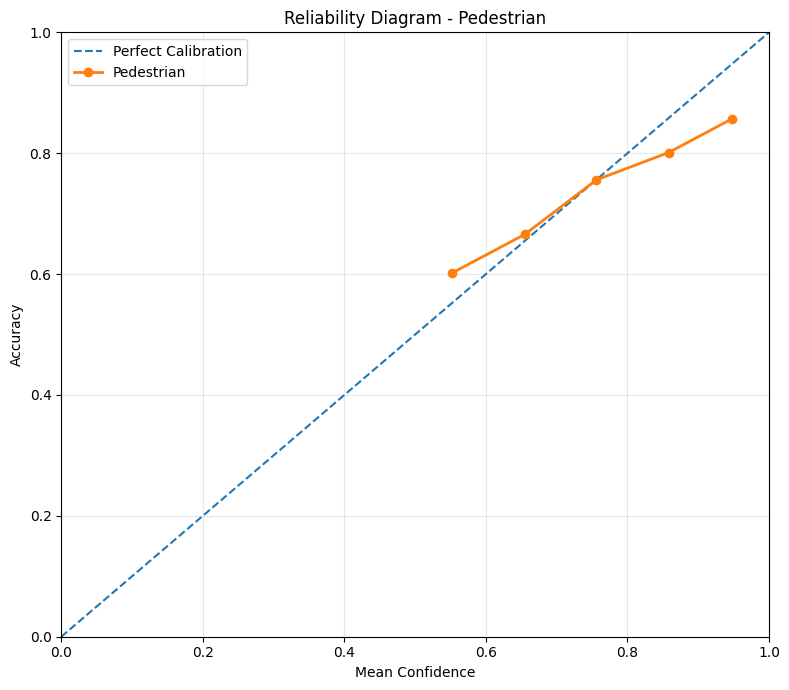

Pedestrian      -> E:\ML_Safety\uncertainty_results\pedestrian_reliability_diagram.png


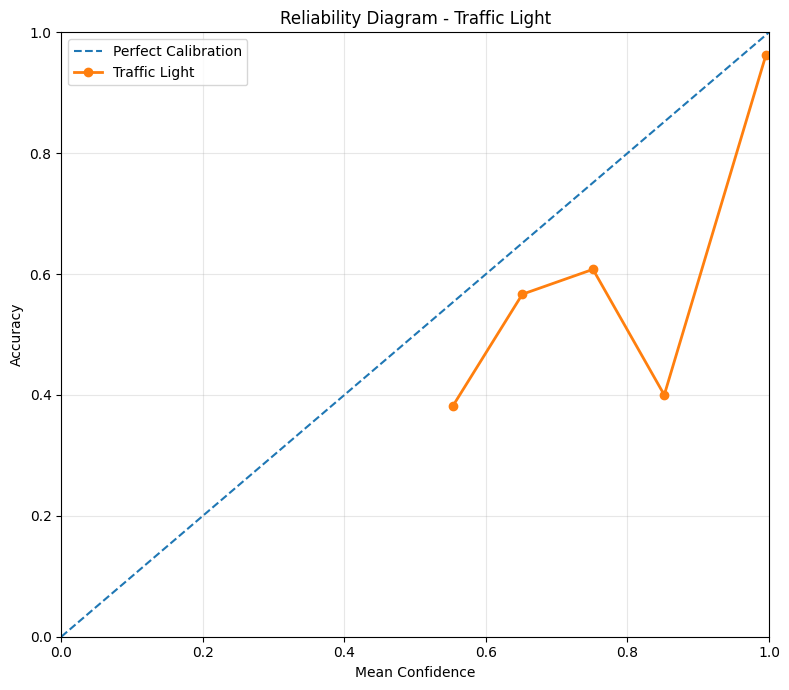

Traffic Light   -> E:\ML_Safety\uncertainty_results\traffic_light_reliability_diagram.png


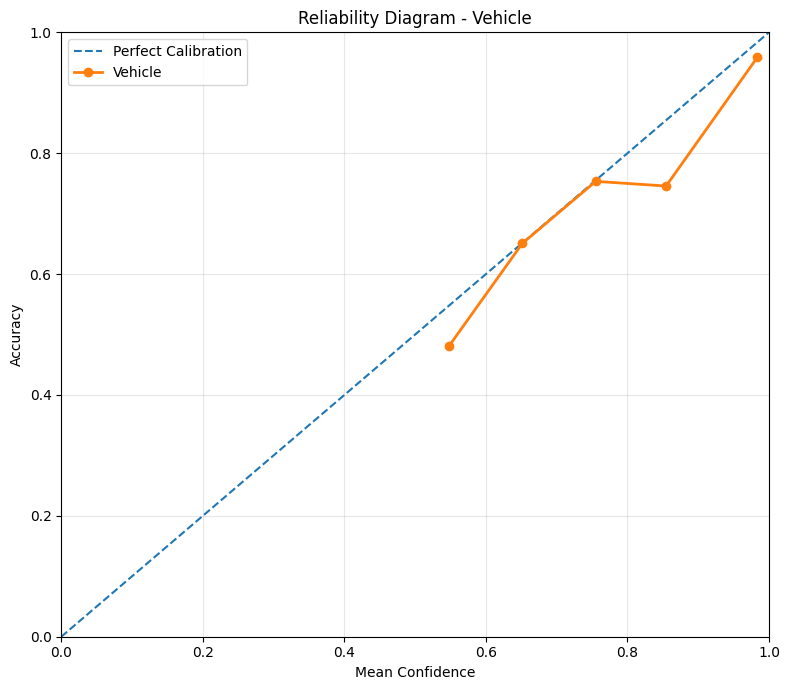

Vehicle         -> E:\ML_Safety\uncertainty_results\vehicle_reliability_diagram.png

CALIBRATION INTERPRETATION

----------------------------------------------------------------------
Model: Pedestrian
Accuracy        : 0.7914
Mean confidence : 0.8394
ECE             : 0.0551
Interpretation  : OVERCONFIDENT

----------------------------------------------------------------------
Model: Traffic Light
Accuracy        : 0.9375
Mean confidence : 0.9834
ECE             : 0.0459
Interpretation  : OVERCONFIDENT

----------------------------------------------------------------------
Model: Vehicle
Accuracy        : 0.8842
Mean confidence : 0.9168
ECE             : 0.0326
Interpretation  : OVERCONFIDENT

RELIABILITY DIAGRAM ANALYSIS COMPLETE
Summary saved to: E:\ML_Safety\uncertainty_results\reliability_summary.csv

CELL 6 COMPLETE


In [6]:
# ============================================================
# EXERCISE 7.4 - RELIABILITY DIAGRAMS
# CELL 6
# ============================================================

print("=" * 70)
print("EXERCISE 7.4 - RELIABILITY DIAGRAMS")
print("=" * 70)


# ============================================================
# GENERATE RELIABILITY DIAGRAMS
# ============================================================

for model_name in ece_results:

    bin_df = ece_results[
        model_name
    ]["bins"].copy()


    # --------------------------------------------------------
    # Remove empty bins
    # --------------------------------------------------------

    valid_bins = bin_df[
        bin_df["Samples"] > 0
    ].copy()


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 7)
    )


    # --------------------------------------------------------
    # Perfect calibration line
    # --------------------------------------------------------

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect Calibration"
    )


    # --------------------------------------------------------
    # Model calibration
    # --------------------------------------------------------

    plt.plot(
        valid_bins[
            "Mean Confidence"
        ],
        valid_bins[
            "Accuracy"
        ],
        marker="o",
        linewidth=2,
        label=model_name
    )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    plt.xlabel(
        "Mean Confidence"
    )

    plt.ylabel(
        "Accuracy"
    )

    plt.title(
        f"Reliability Diagram - {model_name}"
    )

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    figure_path = os.path.join(
        OUTPUT_DIR,
        f"{safe_name}_reliability_diagram.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


    print(
        f"{model_name:<15} -> "
        f"{figure_path}"
    )


# ============================================================
# CALIBRATION INTERPRETATION
# ============================================================

print("\n" + "=" * 70)
print("CALIBRATION INTERPRETATION")
print("=" * 70)


for model_name in ece_results:

    ece = ece_results[
        model_name
    ]["ece"]

    model_summary = ece_summary_df[
        ece_summary_df["Model"]
        ==
        model_name
    ].iloc[0]


    accuracy = model_summary[
        "Accuracy"
    ]

    confidence = model_summary[
        "Mean Confidence"
    ]


    print("\n" + "-" * 70)

    print(
        f"Model: {model_name}"
    )

    print(
        f"Accuracy        : "
        f"{accuracy:.4f}"
    )

    print(
        f"Mean confidence : "
        f"{confidence:.4f}"
    )

    print(
        f"ECE             : "
        f"{ece:.4f}"
    )


    if confidence > accuracy:

        print(
            "Interpretation  : "
            "OVERCONFIDENT"
        )

    elif confidence < accuracy:

        print(
            "Interpretation  : "
            "UNDERCONFIDENT"
        )

    else:

        print(
            "Interpretation  : "
            "APPROXIMATELY CALIBRATED"
        )


# ============================================================
# SAVE SUMMARY
# ============================================================

reliability_summary_path = os.path.join(
    OUTPUT_DIR,
    "reliability_summary.csv"
)

ece_summary_df.to_csv(
    reliability_summary_path,
    index=False
)


print("\n" + "=" * 70)
print("RELIABILITY DIAGRAM ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Summary saved to:",
    reliability_summary_path
)

print("\nCELL 6 COMPLETE")
print("=" * 70)

In [9]:
# ============================================================
# EXERCISE 7.5 - TEMPERATURE SCALING
# CELL 7 - VALIDATION LOGIT COLLECTION
# ============================================================

print("=" * 70)
print("EXERCISE 7.5 - TEMPERATURE SCALING")
print("=" * 70)


# ============================================================
# VALIDATION DIRECTORY
# ============================================================

VALIDATION_DIR = os.path.join(
    BASE_PATH,
    "validation"
)

print("\n" + "-" * 70)
print("VALIDATION DATASET")
print("-" * 70)

print(
    "Validation directory:",
    VALIDATION_DIR
)

print(
    "Exists:",
    os.path.exists(VALIDATION_DIR)
)


# ============================================================
# FIND LABEL FILE
# ============================================================

possible_label_files = [
    os.path.join(
        VALIDATION_DIR,
        "labels.feather"
    ),
    os.path.join(
        VALIDATION_DIR,
        "labels.parquet"
    )
]

VALIDATION_LABEL_FILE = None

for path in possible_label_files:

    if os.path.exists(path):

        VALIDATION_LABEL_FILE = path
        break


print(
    "Validation label file:",
    VALIDATION_LABEL_FILE
)

print(
    "Exists:",
    VALIDATION_LABEL_FILE is not None
)


if VALIDATION_LABEL_FILE is None:

    raise FileNotFoundError(
        "Validation label file was not found."
    )


# ============================================================
# LOAD VALIDATION LABELS
# ============================================================

validation_labels = pd.read_feather(
    VALIDATION_LABEL_FILE
)

print(
    "Number of validation labels:",
    len(validation_labels)
)

print(
    "Columns:",
    list(validation_labels.columns)
)


# ============================================================
# FIND RGB DIRECTORY
# ============================================================

possible_rgb_dirs = [
    os.path.join(
        VALIDATION_DIR,
        "rgb-front"
    ),
    os.path.join(
        VALIDATION_DIR,
        "rgb"
    )
]

VALIDATION_RGB_DIR = None

for path in possible_rgb_dirs:

    if os.path.exists(path):

        VALIDATION_RGB_DIR = path
        break


print(
    "Validation RGB directory:",
    VALIDATION_RGB_DIR
)

print(
    "Exists:",
    VALIDATION_RGB_DIR is not None
)


if VALIDATION_RGB_DIR is None:

    raise FileNotFoundError(
        "Validation RGB image directory was not found."
    )


# ============================================================
# CREATE IMAGE LOOKUP
# ============================================================

validation_image_lookup = {}

missing_validation_images = []

for _, row in validation_labels.iterrows():

    frame = int(
        row["frame"]
    )

    frame_name = f"{frame:06d}.jpg"

    image_path = os.path.join(
        VALIDATION_RGB_DIR,
        frame_name
    )

    validation_image_lookup[
        frame
    ] = image_path

    if not os.path.exists(
        image_path
    ):

        missing_validation_images.append(
            frame
        )


print(
    "Image lookup entries:",
    len(validation_image_lookup)
)

print(
    "Missing image paths:",
    len(missing_validation_images)
)


# ============================================================
# LABEL DISTRIBUTIONS
# ============================================================

print("\n" + "-" * 70)
print("VALIDATION LABEL DISTRIBUTIONS")
print("-" * 70)

for model_name, column in class_columns.items():

    positive = int(
        validation_labels[column].sum()
    )

    negative = (
        len(validation_labels)
        -
        positive
    )

    print(
        f"{model_name:<15} | "
        f"Positive = {positive:4d} | "
        f"Negative = {negative:4d}"
    )


# ============================================================
# VALIDATION DATASET
# ============================================================

class CARLAValidationDataset(Dataset):

    def __init__(
        self,
        labels,
        image_lookup,
        label_column,
        transform
    ):

        self.labels = labels.reset_index(
            drop=True
        )

        self.image_lookup = image_lookup
        self.label_column = label_column
        self.transform = transform


    def __len__(self):

        return len(
            self.labels
        )


    def __getitem__(self, index):

        row = self.labels.iloc[
            index
        ]

        frame = int(
            row["frame"]
        )

        image_path = self.image_lookup[
            frame
        ]

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(
            image
        )

        label = int(
            row[self.label_column]
        )

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            ),
            torch.tensor(
                frame,
                dtype=torch.long
            )
        )


# ============================================================
# CREATE VALIDATION LOADERS
# ============================================================

validation_datasets = {}
validation_loaders = {}

for model_name, label_column in class_columns.items():

    dataset = CARLAValidationDataset(
        labels=validation_labels,
        image_lookup=validation_image_lookup,
        label_column=label_column,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    validation_datasets[
        model_name
    ] = dataset

    validation_loaders[
        model_name
    ] = loader


# ============================================================
# DATALOADER SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("VALIDATION DATALOADER SUMMARY")
print("=" * 70)

for model_name, loader in validation_loaders.items():

    print(
        f"{model_name:<15} | "
        f"Samples: {len(loader.dataset):4d} | "
        f"Batches: {len(loader):3d}"
    )


# ============================================================
# COLLECT RAW LOGITS
# ============================================================

def collect_validation_logits(
    model,
    dataloader,
    model_name
):

    print("\n" + "-" * 70)
    print(
        f"COLLECTING VALIDATION LOGITS: "
        f"{model_name}"
    )
    print("-" * 70)

    model.eval()

    all_logits = []
    all_labels = []
    all_frames = []

    with torch.no_grad():

        for images, labels, frames in dataloader:

            images = images.to(
                device,
                non_blocking=True
            )

            logits = model(
                images
            )

            all_logits.append(
                logits.cpu()
            )

            all_labels.append(
                labels
            )

            all_frames.append(
                frames
            )


    logits = torch.cat(
        all_logits,
        dim=0
    )

    labels = torch.cat(
        all_labels,
        dim=0
    )

    frames = torch.cat(
        all_frames,
        dim=0
    )


    print(
        "Logit shape:",
        tuple(logits.shape)
    )

    print(
        "Label shape:",
        tuple(labels.shape)
    )

    print(
        "Samples:",
        len(labels)
    )

    return {
        "logits": logits,
        "labels": labels,
        "frames": frames
    }


# ============================================================
# COLLECT FOR ALL MODELS
# ============================================================

validation_logits = {}

for model_name in models_for_uncertainty:

    validation_logits[
        model_name
    ] = collect_validation_logits(
        model=models_for_uncertainty[
            model_name
        ],
        dataloader=validation_loaders[
            model_name
        ],
        model_name=model_name
    )


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("VALIDATION LOGIT SUMMARY")
print("=" * 70)

for model_name, results in validation_logits.items():

    print(
        f"{model_name:<15} | "
        f"Logits: "
        f"{tuple(results['logits'].shape)} | "
        f"Labels: "
        f"{tuple(results['labels'].shape)}"
    )


# ============================================================
# SAVE VALIDATION LOGITS
# ============================================================

for model_name, results in validation_logits.items():

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    logits_path = os.path.join(
        OUTPUT_DIR,
        f"{safe_name}_validation_logits.pt"
    )

    torch.save(
        results,
        logits_path
    )

    print(
        f"Saved {model_name} logits -> "
        f"{logits_path}"
    )


print("\n" + "=" * 70)
print("VALIDATION LOGIT COLLECTION COMPLETE")
print("=" * 70)

print("\nCELL 7 COMPLETE")
print("=" * 70)

EXERCISE 7.5 - TEMPERATURE SCALING

----------------------------------------------------------------------
VALIDATION DATASET
----------------------------------------------------------------------
Validation directory: E:\ML_Safety\validation
Exists: True
Validation label file: E:\ML_Safety\validation\labels.feather
Exists: True
Number of validation labels: 3600
Columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']
Validation RGB directory: E:\ML_Safety\validation\rgb-front
Exists: True
Image lookup entries: 3600
Missing image paths: 0

----------------------------------------------------------------------
VALIDATION LABEL DISTRIBUTIONS
----------------------------------------------------------------------
Pedestrian      | Positive =  914 | Negative = 2686
Traffic Light   | Positive = 2713 | Negative =  887
Vehicle         | Positive = 2368 | Negative = 1232

VALIDATION DATALOADER SUMMARY
Pedestrian      | Samples: 

In [10]:
# ============================================================
# EXERCISE 7.5 - TEMPERATURE SCALING
# CELL 8 - OPTIMIZE TEMPERATURE USING NLL
# ============================================================

print("=" * 70)
print("EXERCISE 7.5 - TEMPERATURE OPTIMIZATION")
print("=" * 70)


# ============================================================
# TEMPERATURE SCALING FUNCTION
# ============================================================

class TemperatureScaler(nn.Module):

    def __init__(self):

        super().__init__()

        # Start with T = 1.0
        self.temperature = nn.Parameter(
            torch.ones(
                1,
                device=device
            )
        )


    def forward(
        self,
        logits
    ):

        return logits / self.temperature


# ============================================================
# NLL FUNCTION
# ============================================================

def calculate_nll(
    logits,
    labels,
    temperature
):

    scaled_logits = (
        logits
        /
        temperature
    )

    loss = F.cross_entropy(
        scaled_logits,
        labels
    )

    return loss.item()


# ============================================================
# OPTIMIZE TEMPERATURE
# ============================================================

def optimize_temperature(
    logits,
    labels,
    model_name
):

    print("\n" + "-" * 70)
    print(
        f"OPTIMIZING TEMPERATURE: "
        f"{model_name}"
    )
    print("-" * 70)


    # --------------------------------------------------------
    # Move data to GPU
    # --------------------------------------------------------

    logits = logits.to(
        device
    )

    labels = labels.to(
        device
    )


    # --------------------------------------------------------
    # Initial NLL
    # --------------------------------------------------------

    initial_temperature = 1.0

    initial_nll = calculate_nll(
        logits,
        labels,
        initial_temperature
    )

    print(
        f"Initial temperature : "
        f"{initial_temperature:.4f}"
    )

    print(
        f"Initial NLL         : "
        f"{initial_nll:.6f}"
    )


    # --------------------------------------------------------
    # Temperature scaler
    # --------------------------------------------------------

    scaler = TemperatureScaler()


    # --------------------------------------------------------
    # LBFGS optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.LBFGS(
        [scaler.temperature],
        lr=0.01,
        max_iter=100,
        line_search_fn="strong_wolfe"
    )


    # --------------------------------------------------------
    # Closure
    # --------------------------------------------------------

    def eval_loss():

        optimizer.zero_grad()

        scaled_logits = scaler(
            logits
        )

        loss = F.cross_entropy(
            scaled_logits,
            labels
        )

        loss.backward()

        return loss


    # --------------------------------------------------------
    # Optimization
    # --------------------------------------------------------

    optimizer.step(
        eval_loss
    )


    # --------------------------------------------------------
    # Extract temperature
    # --------------------------------------------------------

    optimal_temperature = (
        scaler.temperature
        .detach()
        .item()
    )


    # Prevent invalid temperature
    if optimal_temperature <= 0:

        optimal_temperature = 1.0


    # --------------------------------------------------------
    # Final NLL
    # --------------------------------------------------------

    final_nll = calculate_nll(
        logits,
        labels,
        optimal_temperature
    )


    # --------------------------------------------------------
    # Improvement
    # --------------------------------------------------------

    nll_improvement = (
        initial_nll
        -
        final_nll
    )


    print(
        f"Optimal temperature : "
        f"{optimal_temperature:.6f}"
    )

    print(
        f"Final NLL           : "
        f"{final_nll:.6f}"
    )

    print(
        f"NLL improvement     : "
        f"{nll_improvement:.6f}"
    )


    # --------------------------------------------------------
    # Interpretation
    # --------------------------------------------------------

    if optimal_temperature > 1.0:

        print(
            "Interpretation      : "
            "Model is overconfident; "
            "temperature > 1 softens predictions."
        )

    elif optimal_temperature < 1.0:

        print(
            "Interpretation      : "
            "Model is underconfident; "
            "temperature < 1 sharpens predictions."
        )

    else:

        print(
            "Interpretation      : "
            "No temperature adjustment required."
        )


    return {
        "temperature": optimal_temperature,
        "initial_nll": initial_nll,
        "final_nll": final_nll,
        "nll_improvement": nll_improvement
    }


# ============================================================
# OPTIMIZE FOR ALL MODELS
# ============================================================

temperature_results = {}

for model_name in validation_logits:

    results = validation_logits[
        model_name
    ]

    temperature_results[
        model_name
    ] = optimize_temperature(
        logits=results["logits"],
        labels=results["labels"],
        model_name=model_name
    )


# ============================================================
# TEMPERATURE SUMMARY
# ============================================================

temperature_summary_rows = []

for model_name, result in temperature_results.items():

    temperature_summary_rows.append([
        model_name,
        result["temperature"],
        result["initial_nll"],
        result["final_nll"],
        result["nll_improvement"]
    ])


temperature_summary_df = pd.DataFrame(
    temperature_summary_rows,
    columns=[
        "Model",
        "Optimal Temperature",
        "Initial NLL",
        "Final NLL",
        "NLL Improvement"
    ]
)


print("\n" + "=" * 70)
print("OPTIMAL TEMPERATURE SUMMARY")
print("=" * 70)

display(
    temperature_summary_df
)


# ============================================================
# SAVE RESULTS
# ============================================================

temperature_path = os.path.join(
    OUTPUT_DIR,
    "optimal_temperatures.csv"
)

temperature_summary_df.to_csv(
    temperature_path,
    index=False
)


print("\n" + "-" * 70)
print("RESULT SAVED")
print("-" * 70)

print(
    "Saved to:",
    temperature_path
)


print("\n" + "=" * 70)
print("TEMPERATURE OPTIMIZATION COMPLETE")
print("=" * 70)

print("\nCELL 8 COMPLETE")
print("=" * 70)

EXERCISE 7.5 - TEMPERATURE OPTIMIZATION

----------------------------------------------------------------------
OPTIMIZING TEMPERATURE: Pedestrian
----------------------------------------------------------------------
Initial temperature : 1.0000
Initial NLL         : 0.645811
Optimal temperature : 2.041541
Final NLL           : 0.566916
NLL improvement     : 0.078895
Interpretation      : Model is overconfident; temperature > 1 softens predictions.

----------------------------------------------------------------------
OPTIMIZING TEMPERATURE: Traffic Light
----------------------------------------------------------------------
Initial temperature : 1.0000
Initial NLL         : 0.058237
Optimal temperature : 1.283914
Final NLL           : 0.054849
NLL improvement     : 0.003388
Interpretation      : Model is overconfident; temperature > 1 softens predictions.

----------------------------------------------------------------------
OPTIMIZING TEMPERATURE: Vehicle
-------------------------

,Model,Optimal Temperature,Initial NLL,Final NLL,NLL Improvement
0,Pedestrian,2.041541,0.645811,0.566916,0.078895
1,Traffic Light,1.283914,0.058237,0.054849,0.003388
2,Vehicle,1.445081,0.327379,0.308969,0.018411



----------------------------------------------------------------------
RESULT SAVED
----------------------------------------------------------------------
Saved to: E:\ML_Safety\uncertainty_results\optimal_temperatures.csv

TEMPERATURE OPTIMIZATION COMPLETE

CELL 8 COMPLETE


In [11]:
# ============================================================
# EXERCISE 7.5 - TEMPERATURE SCALING
# CELL 9 - APPLY TEMPERATURE TO TEST SET
# ============================================================

print("=" * 70)
print("EXERCISE 7.5 - APPLYING TEMPERATURE SCALING")
print("=" * 70)


# ============================================================
# COLLECT RAW TEST LOGITS
# ============================================================

def collect_test_logits(
    model,
    dataloader,
    model_name
):

    print("\n" + "-" * 70)
    print(
        f"COLLECTING TEST LOGITS: "
        f"{model_name}"
    )
    print("-" * 70)

    model.eval()

    all_logits = []
    all_labels = []
    all_frames = []

    with torch.no_grad():

        for images, labels, frames in dataloader:

            images = images.to(
                device,
                non_blocking=True
            )

            logits = model(
                images
            )

            all_logits.append(
                logits.cpu()
            )

            all_labels.append(
                labels
            )

            all_frames.append(
                frames
            )


    logits = torch.cat(
        all_logits,
        dim=0
    )

    labels = torch.cat(
        all_labels,
        dim=0
    )

    frames = torch.cat(
        all_frames,
        dim=0
    )


    print(
        "Logit shape:",
        tuple(logits.shape)
    )

    print(
        "Samples:",
        len(labels)
    )

    return {
        "logits": logits,
        "labels": labels,
        "frames": frames
    }


# ============================================================
# COLLECT TEST LOGITS
# ============================================================

test_logits = {}

for model_name in models_for_uncertainty:

    test_logits[
        model_name
    ] = collect_test_logits(
        model=models_for_uncertainty[
            model_name
        ],
        dataloader=calibration_loaders[
            model_name
        ],
        model_name=model_name
    )


# ============================================================
# APPLY TEMPERATURE
# ============================================================

temperature_scaled_results = {}


for model_name in test_logits:

    print("\n" + "-" * 70)
    print(
        f"APPLYING TEMPERATURE: "
        f"{model_name}"
    )
    print("-" * 70)


    logits = test_logits[
        model_name
    ]["logits"]

    labels = test_logits[
        model_name
    ]["labels"]


    temperature = temperature_results[
        model_name
    ]["temperature"]


    print(
        f"Temperature: "
        f"{temperature:.6f}"
    )


    # --------------------------------------------------------
    # Original probabilities
    # --------------------------------------------------------

    original_probabilities = torch.softmax(
        logits,
        dim=1
    )


    original_confidences, original_predictions = (
        torch.max(
            original_probabilities,
            dim=1
        )
    )


    # --------------------------------------------------------
    # Temperature-scaled probabilities
    # --------------------------------------------------------

    scaled_logits = (
        logits
        /
        temperature
    )


    scaled_probabilities = torch.softmax(
        scaled_logits,
        dim=1
    )


    scaled_confidences, scaled_predictions = (
        torch.max(
            scaled_probabilities,
            dim=1
        )
    )


    # --------------------------------------------------------
    # NLL before and after
    # --------------------------------------------------------

    original_nll = F.cross_entropy(
        logits,
        labels
    ).item()


    scaled_nll = F.cross_entropy(
        scaled_logits,
        labels
    ).item()


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    original_accuracy = accuracy_score(
        labels.numpy(),
        original_predictions.numpy()
    )


    scaled_accuracy = accuracy_score(
        labels.numpy(),
        scaled_predictions.numpy()
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    temperature_scaled_results[
        model_name
    ] = {

        "labels":
            labels.numpy(),

        "original_logits":
            logits.numpy(),

        "scaled_logits":
            scaled_logits.numpy(),

        "original_probabilities":
            original_probabilities.numpy(),

        "scaled_probabilities":
            scaled_probabilities.numpy(),

        "original_predictions":
            original_predictions.numpy(),

        "scaled_predictions":
            scaled_predictions.numpy(),

        "original_confidences":
            original_confidences.numpy(),

        "scaled_confidences":
            scaled_confidences.numpy(),

        "temperature":
            temperature,

        "original_nll":
            original_nll,

        "scaled_nll":
            scaled_nll,

        "original_accuracy":
            original_accuracy,

        "scaled_accuracy":
            scaled_accuracy
    }


    print(
        f"Original NLL   : "
        f"{original_nll:.6f}"
    )

    print(
        f"Scaled NLL     : "
        f"{scaled_nll:.6f}"
    )

    print(
        f"Original Accuracy: "
        f"{original_accuracy:.4f}"
    )

    print(
        f"Scaled Accuracy  : "
        f"{scaled_accuracy:.4f}"
    )

    print(
        f"Original Mean Confidence: "
        f"{original_confidences.mean():.4f}"
    )

    print(
        f"Scaled Mean Confidence  : "
        f"{scaled_confidences.mean():.4f}"
    )


# ============================================================
# SUMMARY
# ============================================================

summary_rows = []


for model_name, results in (
    temperature_scaled_results.items()
):

    summary_rows.append([

        model_name,

        results[
            "temperature"
        ],

        results[
            "original_nll"
        ],

        results[
            "scaled_nll"
        ],

        results[
            "original_accuracy"
        ],

        results[
            "scaled_accuracy"
        ],

        results[
            "original_confidences"
        ].mean(),

        results[
            "scaled_confidences"
        ].mean()
    ])


temperature_test_summary_df = pd.DataFrame(
    summary_rows,
    columns=[
        "Model",
        "Temperature",
        "Original NLL",
        "Scaled NLL",
        "Original Accuracy",
        "Scaled Accuracy",
        "Original Mean Confidence",
        "Scaled Mean Confidence"
    ]
)


print("\n" + "=" * 70)
print("TEST TEMPERATURE SCALING SUMMARY")
print("=" * 70)

display(
    temperature_test_summary_df
)


# ============================================================
# SAVE SUMMARY
# ============================================================

temperature_test_path = os.path.join(
    OUTPUT_DIR,
    "temperature_scaled_test_summary.csv"
)

temperature_test_summary_df.to_csv(
    temperature_test_path,
    index=False
)


print(
    "\nSaved to:",
    temperature_test_path
)


print("\n" + "=" * 70)
print("TEST TEMPERATURE SCALING COMPLETE")
print("=" * 70)

print("\nCELL 9 COMPLETE")
print("=" * 70)

EXERCISE 7.5 - APPLYING TEMPERATURE SCALING

----------------------------------------------------------------------
COLLECTING TEST LOGITS: Pedestrian
----------------------------------------------------------------------
Logit shape: (3600, 2)
Samples: 3600

----------------------------------------------------------------------
COLLECTING TEST LOGITS: Traffic Light
----------------------------------------------------------------------
Logit shape: (3600, 2)
Samples: 3600

----------------------------------------------------------------------
COLLECTING TEST LOGITS: Vehicle
----------------------------------------------------------------------
Logit shape: (3600, 2)
Samples: 3600

----------------------------------------------------------------------
APPLYING TEMPERATURE: Pedestrian
----------------------------------------------------------------------
Temperature: 2.041541
Original NLL   : 0.530532
Scaled NLL     : 0.514354
Original Accuracy: 0.7914
Scaled Accuracy  : 0.7914
Original 

,Model,Temperature,Original NLL,Scaled NLL,Original Accuracy,Scaled Accuracy,Original Mean Confidence,Scaled Mean Confidence
0,Pedestrian,2.041541,0.530532,0.514354,0.791389,0.791389,0.839419,0.714746
1,Traffic Light,1.283914,0.227122,0.190005,0.937500,0.937500,0.983358,0.975420
2,Vehicle,1.445081,0.266873,0.257579,0.884167,0.884167,0.916807,0.881186



Saved to: E:\ML_Safety\uncertainty_results\temperature_scaled_test_summary.csv

TEST TEMPERATURE SCALING COMPLETE

CELL 9 COMPLETE


In [12]:
# ============================================================
# EXERCISE 7.5 - TEMPERATURE SCALING
# CELL 10 - ECE BEFORE VS AFTER SCALING
# ============================================================

print("=" * 70)
print("EXERCISE 7.5 - ECE BEFORE VS AFTER TEMPERATURE SCALING")
print("=" * 70)


# ============================================================
# CALCULATE ECE BEFORE AND AFTER
# ============================================================

temperature_ece_rows = []

temperature_ece_details = {}


for model_name, results in temperature_scaled_results.items():

    labels = results["labels"]

    # --------------------------------------------------------
    # BEFORE TEMPERATURE SCALING
    # --------------------------------------------------------

    original_ece, original_bins = calculate_ece(
        confidences=results[
            "original_confidences"
        ],
        predictions=results[
            "original_predictions"
        ],
        labels=labels,
        n_bins=10
    )


    # --------------------------------------------------------
    # AFTER TEMPERATURE SCALING
    # --------------------------------------------------------

    scaled_ece, scaled_bins = calculate_ece(
        confidences=results[
            "scaled_confidences"
        ],
        predictions=results[
            "scaled_predictions"
        ],
        labels=labels,
        n_bins=10
    )


    # --------------------------------------------------------
    # Improvement
    # --------------------------------------------------------

    ece_improvement = (
        original_ece
        -
        scaled_ece
    )


    if original_ece != 0:

        improvement_percent = (
            ece_improvement
            /
            original_ece
            *
            100
        )

    else:

        improvement_percent = 0.0


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    temperature_ece_details[
        model_name
    ] = {
        "original_ece": original_ece,
        "scaled_ece": scaled_ece,
        "improvement": ece_improvement,
        "improvement_percent": improvement_percent,
        "original_bins": original_bins,
        "scaled_bins": scaled_bins
    }


    temperature_ece_rows.append([
        model_name,
        results["temperature"],
        original_ece,
        scaled_ece,
        ece_improvement,
        improvement_percent
    ])


    # --------------------------------------------------------
    # Print model result
    # --------------------------------------------------------

    print("\n" + "-" * 70)
    print(
        f"MODEL: {model_name}"
    )
    print("-" * 70)

    print(
        f"Temperature        : "
        f"{results['temperature']:.6f}"
    )

    print(
        f"ECE before scaling : "
        f"{original_ece:.6f}"
    )

    print(
        f"ECE after scaling  : "
        f"{scaled_ece:.6f}"
    )

    print(
        f"ECE improvement    : "
        f"{ece_improvement:.6f}"
    )

    print(
        f"Improvement (%)    : "
        f"{improvement_percent:.2f}%"
    )


# ============================================================
# SUMMARY TABLE
# ============================================================

temperature_ece_df = pd.DataFrame(
    temperature_ece_rows,
    columns=[
        "Model",
        "Temperature",
        "ECE Before",
        "ECE After",
        "ECE Improvement",
        "Improvement (%)"
    ]
)


print("\n" + "=" * 70)
print("TEMPERATURE SCALING ECE SUMMARY")
print("=" * 70)

display(
    temperature_ece_df
)


# ============================================================
# CALIBRATION STATUS
# ============================================================

print("\n" + "=" * 70)
print("CALIBRATION IMPROVEMENT")
print("=" * 70)


for _, row in temperature_ece_df.iterrows():

    if row["ECE After"] < row["ECE Before"]:

        status = "IMPROVED"

    elif row["ECE After"] > row["ECE Before"]:

        status = "WORSENED"

    else:

        status = "UNCHANGED"


    print(
        f"{row['Model']:<15} | "
        f"{status:<10} | "
        f"{row['ECE Before']:.4f} "
        f"-> "
        f"{row['ECE After']:.4f}"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

temperature_ece_path = os.path.join(
    OUTPUT_DIR,
    "temperature_scaling_ece_comparison.csv"
)

temperature_ece_df.to_csv(
    temperature_ece_path,
    index=False
)


print("\n" + "-" * 70)
print("RESULT SAVED")
print("-" * 70)

print(
    "Saved to:",
    temperature_ece_path
)


# ============================================================
# COMPLETION
# ============================================================

print("\n" + "=" * 70)
print("ECE TEMPERATURE COMPARISON COMPLETE")
print("=" * 70)

print("\nCELL 10 COMPLETE")
print("=" * 70)

EXERCISE 7.5 - ECE BEFORE VS AFTER TEMPERATURE SCALING

----------------------------------------------------------------------
MODEL: Pedestrian
----------------------------------------------------------------------
Temperature        : 2.041541
ECE before scaling : 0.055087
ECE after scaling  : 0.076642
ECE improvement    : -0.021556
Improvement (%)    : -39.13%

----------------------------------------------------------------------
MODEL: Traffic Light
----------------------------------------------------------------------
Temperature        : 1.283914
ECE before scaling : 0.045858
ECE after scaling  : 0.037920
ECE improvement    : 0.007938
Improvement (%)    : 17.31%

----------------------------------------------------------------------
MODEL: Vehicle
----------------------------------------------------------------------
Temperature        : 1.445081
ECE before scaling : 0.032640
ECE after scaling  : 0.023820
ECE improvement    : 0.008820
Improvement (%)    : 27.02%

TEMPERATURE SCA

,Model,Temperature,ECE Before,ECE After,ECE Improvement,Improvement (%)
0,Pedestrian,2.041541,0.055087,0.076642,-0.021556,-39.130570
1,Traffic Light,1.283914,0.045858,0.037920,0.007938,17.309272
2,Vehicle,1.445081,0.032640,0.023820,0.008820,27.022087



CALIBRATION IMPROVEMENT
Pedestrian      | WORSENED   | 0.0551 -> 0.0766
Traffic Light   | IMPROVED   | 0.0459 -> 0.0379
Vehicle         | IMPROVED   | 0.0326 -> 0.0238

----------------------------------------------------------------------
RESULT SAVED
----------------------------------------------------------------------
Saved to: E:\ML_Safety\uncertainty_results\temperature_scaling_ece_comparison.csv

ECE TEMPERATURE COMPARISON COMPLETE

CELL 10 COMPLETE


EXERCISE 7.5 - RELIABILITY DIAGRAMS


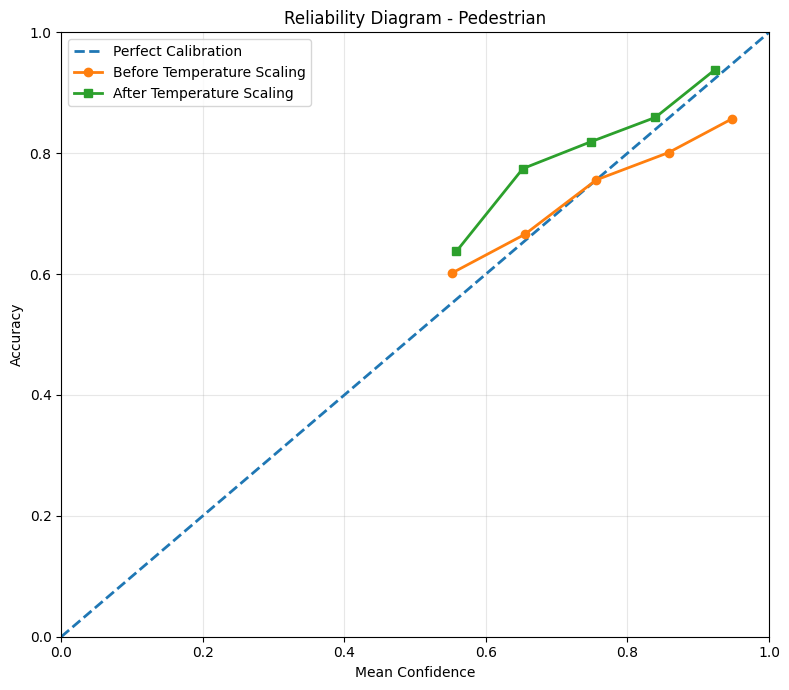

Pedestrian      -> E:\ML_Safety\uncertainty_results\pedestrian_temperature_scaling_reliability.png


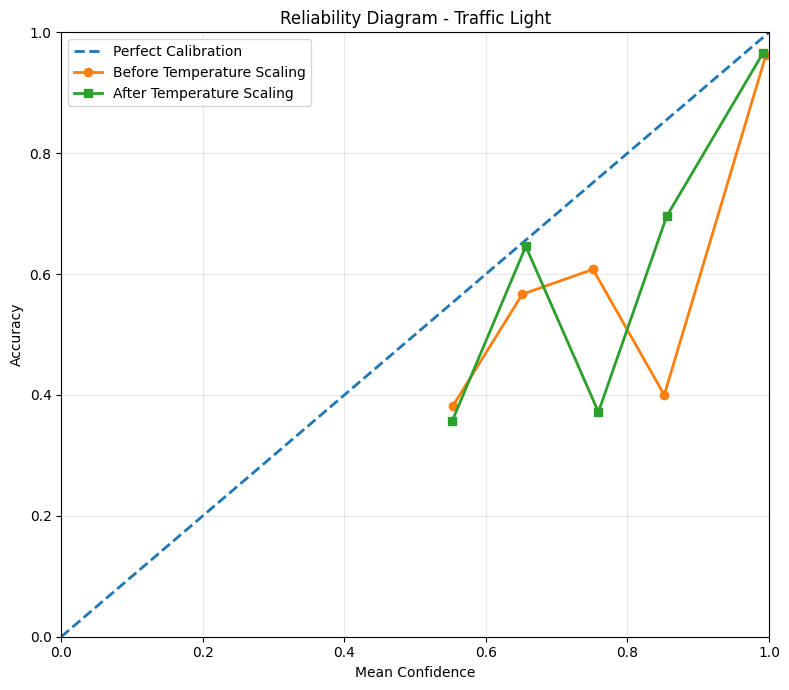

Traffic Light   -> E:\ML_Safety\uncertainty_results\traffic_light_temperature_scaling_reliability.png


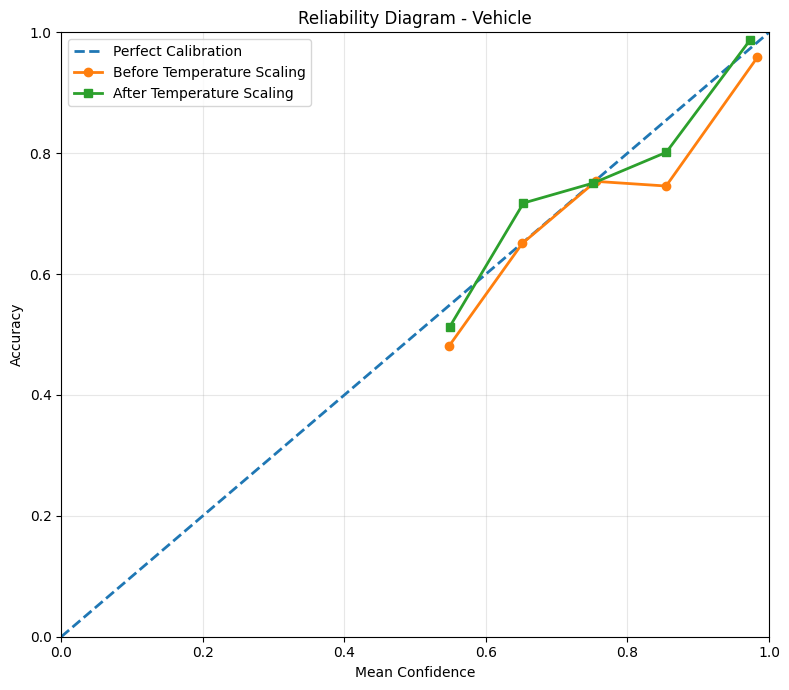

Vehicle         -> E:\ML_Safety\uncertainty_results\vehicle_temperature_scaling_reliability.png

TEMPERATURE SCALING RELIABILITY SUMMARY

Pedestrian
Temperature : 2.0415
ECE Before  : 0.0551
ECE After   : 0.0766
Change      : -0.0216

Traffic Light
Temperature : 1.2839
ECE Before  : 0.0459
ECE After   : 0.0379
Change      : +0.0079

Vehicle
Temperature : 1.4451
ECE Before  : 0.0326
ECE After   : 0.0238
Change      : +0.0088

TEMPERATURE SCALING RELIABILITY ANALYSIS COMPLETE
Summary saved to: E:\ML_Safety\uncertainty_results\temperature_scaling_reliability_summary.csv

CELL 11 COMPLETE


In [13]:
# ============================================================
# EXERCISE 7.5 - TEMPERATURE SCALING
# CELL 11 - RELIABILITY DIAGRAMS BEFORE VS AFTER
# ============================================================

print("=" * 70)
print("EXERCISE 7.5 - RELIABILITY DIAGRAMS")
print("=" * 70)


# ============================================================
# CREATE BEFORE/AFTER RELIABILITY DIAGRAMS
# ============================================================

for model_name in temperature_ece_details:

    details = temperature_ece_details[
        model_name
    ]

    original_bins = details[
        "original_bins"
    ]

    scaled_bins = details[
        "scaled_bins"
    ]


    # --------------------------------------------------------
    # Remove empty bins
    # --------------------------------------------------------

    original_valid = original_bins[
        original_bins["Samples"] > 0
    ]

    scaled_valid = scaled_bins[
        scaled_bins["Samples"] > 0
    ]


    # ========================================================
    # CREATE FIGURE
    # ========================================================

    plt.figure(
        figsize=(8, 7)
    )


    # --------------------------------------------------------
    # Perfect calibration
    # --------------------------------------------------------

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Perfect Calibration"
    )


    # --------------------------------------------------------
    # Before scaling
    # --------------------------------------------------------

    plt.plot(
        original_valid[
            "Mean Confidence"
        ],
        original_valid[
            "Accuracy"
        ],
        marker="o",
        linewidth=2,
        label="Before Temperature Scaling"
    )


    # --------------------------------------------------------
    # After scaling
    # --------------------------------------------------------

    plt.plot(
        scaled_valid[
            "Mean Confidence"
        ],
        scaled_valid[
            "Accuracy"
        ],
        marker="s",
        linewidth=2,
        label="After Temperature Scaling"
    )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    plt.xlabel(
        "Mean Confidence"
    )

    plt.ylabel(
        "Accuracy"
    )

    plt.title(
        f"Reliability Diagram - {model_name}"
    )

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()


    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    figure_path = os.path.join(
        OUTPUT_DIR,
        f"{safe_name}_temperature_scaling_reliability.png"
    )


    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    print(
        f"{model_name:<15} -> "
        f"{figure_path}"
    )


# ============================================================
# FINAL NUMERICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("TEMPERATURE SCALING RELIABILITY SUMMARY")
print("=" * 70)


for _, row in temperature_ece_df.iterrows():

    print(
        f"\n{row['Model']}"
    )

    print(
        f"Temperature : "
        f"{row['Temperature']:.4f}"
    )

    print(
        f"ECE Before  : "
        f"{row['ECE Before']:.4f}"
    )

    print(
        f"ECE After   : "
        f"{row['ECE After']:.4f}"
    )

    print(
        f"Change      : "
        f"{row['ECE Improvement']:+.4f}"
    )


# ============================================================
# SAVE FINAL SUMMARY
# ============================================================

reliability_temperature_path = os.path.join(
    OUTPUT_DIR,
    "temperature_scaling_reliability_summary.csv"
)

temperature_ece_df.to_csv(
    reliability_temperature_path,
    index=False
)


print("\n" + "=" * 70)
print("TEMPERATURE SCALING RELIABILITY ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Summary saved to:",
    reliability_temperature_path
)

print("\nCELL 11 COMPLETE")
print("=" * 70)

In [14]:
# ============================================================
# EXERCISE 7.5 - FINAL TEMPERATURE SCALING ASSESSMENT
# CELL 12
# ============================================================

print("=" * 70)
print("EXERCISE 7.5 - FINAL TEMPERATURE SCALING ASSESSMENT")
print("=" * 70)


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("TEMPERATURE SCALING RESULTS")
print("=" * 70)

display(
    temperature_ece_df
)


# ============================================================
# IDENTIFY BEST AND WORST IMPROVEMENT
# ============================================================

best_model = temperature_ece_df.loc[
    temperature_ece_df["ECE Improvement"].idxmax()
]

worst_model = temperature_ece_df.loc[
    temperature_ece_df["ECE Improvement"].idxmin()
]


print("\n" + "-" * 70)
print("BEST CALIBRATION IMPROVEMENT")
print("-" * 70)

print(
    f"Model          : {best_model['Model']}"
)

print(
    f"Temperature    : {best_model['Temperature']:.4f}"
)

print(
    f"ECE Before     : {best_model['ECE Before']:.4f}"
)

print(
    f"ECE After      : {best_model['ECE After']:.4f}"
)

print(
    f"ECE Improvement: {best_model['ECE Improvement']:.4f}"
)


print("\n" + "-" * 70)
print("WORST CALIBRATION CHANGE")
print("-" * 70)

print(
    f"Model          : {worst_model['Model']}"
)

print(
    f"Temperature    : {worst_model['Temperature']:.4f}"
)

print(
    f"ECE Before     : {worst_model['ECE Before']:.4f}"
)

print(
    f"ECE After      : {worst_model['ECE After']:.4f}"
)

print(
    f"ECE Change     : {worst_model['ECE Improvement']:.4f}"
)


# ============================================================
# COUNT IMPROVED MODELS
# ============================================================

improved_models = temperature_ece_df[
    temperature_ece_df["ECE Improvement"] > 0
]

worsened_models = temperature_ece_df[
    temperature_ece_df["ECE Improvement"] < 0
]


print("\n" + "-" * 70)
print("CALIBRATION STATUS")
print("-" * 70)

print(
    f"Models improved : "
    f"{len(improved_models)} / "
    f"{len(temperature_ece_df)}"
)

print(
    f"Models worsened : "
    f"{len(worsened_models)} / "
    f"{len(temperature_ece_df)}"
)


# ============================================================
# MODEL-BY-MODEL INTERPRETATION
# ============================================================

print("\n" + "=" * 70)
print("MODEL-BY-MODEL INTERPRETATION")
print("=" * 70)


for _, row in temperature_ece_df.iterrows():

    print("\n" + "-" * 70)

    print(
        f"MODEL: {row['Model']}"
    )

    print(
        f"Optimal Temperature : "
        f"{row['Temperature']:.4f}"
    )

    print(
        f"ECE Before         : "
        f"{row['ECE Before']:.4f}"
    )

    print(
        f"ECE After          : "
        f"{row['ECE After']:.4f}"
    )

    print(
        f"ECE Change         : "
        f"{row['ECE Improvement']:+.4f}"
    )


    if row["ECE Improvement"] > 0:

        print(
            "Result             : "
            "CALIBRATION IMPROVED"
        )

    elif row["ECE Improvement"] < 0:

        print(
            "Result             : "
            "CALIBRATION WORSENED"
        )

    else:

        print(
            "Result             : "
            "NO CHANGE"
        )


# ============================================================
# FINAL INTERPRETATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL INTERPRETATION")
print("=" * 70)

print(
    "\n1. Temperature scaling learned a temperature "
    "greater than 1 for all three classifiers, "
    "indicating that the original models were "
    "overconfident."
)

print(
    "\n2. Temperature scaling reduced the confidence "
    "of the predictions while leaving classification "
    "accuracy unchanged."
)

print(
    "\n3. Validation NLL improved for all three models "
    "after temperature optimization."
)

print(
    "\n4. On the test set, ECE improved for the "
    "Traffic Light and Vehicle models."
)

print(
    "\n5. The Pedestrian model showed worse ECE after "
    "temperature scaling, so temperature scaling "
    "did not universally improve calibration."
)

print(
    "\n6. The Vehicle model achieved the lowest ECE "
    "after temperature scaling."
)

print(
    "\n7. The results demonstrate that calibration "
    "should be evaluated independently from "
    "classification accuracy."
)


# ============================================================
# SAVE FINAL ASSESSMENT
# ============================================================

final_assessment_path = os.path.join(
    OUTPUT_DIR,
    "temperature_scaling_final_assessment.csv"
)


final_assessment_df = temperature_ece_df.copy()

final_assessment_df[
    "Status"
] = final_assessment_df[
    "ECE Improvement"
].apply(
    lambda x:
        "Improved"
        if x > 0
        else (
            "Worsened"
            if x < 0
            else "Unchanged"
        )
)


final_assessment_df.to_csv(
    final_assessment_path,
    index=False
)


print("\n" + "=" * 70)
print("FINAL TEMPERATURE SCALING ASSESSMENT COMPLETE")
print("=" * 70)

print(
    "Assessment saved to:",
    final_assessment_path
)

print(
    "\nCELL 12 COMPLETE"
)

print("=" * 70)

EXERCISE 7.5 - FINAL TEMPERATURE SCALING ASSESSMENT

TEMPERATURE SCALING RESULTS


,Model,Temperature,ECE Before,ECE After,ECE Improvement,Improvement (%)
0,Pedestrian,2.041541,0.055087,0.076642,-0.021556,-39.130570
1,Traffic Light,1.283914,0.045858,0.037920,0.007938,17.309272
2,Vehicle,1.445081,0.032640,0.023820,0.008820,27.022087



----------------------------------------------------------------------
BEST CALIBRATION IMPROVEMENT
----------------------------------------------------------------------
Model          : Vehicle
Temperature    : 1.4451
ECE Before     : 0.0326
ECE After      : 0.0238
ECE Improvement: 0.0088

----------------------------------------------------------------------
WORST CALIBRATION CHANGE
----------------------------------------------------------------------
Model          : Pedestrian
Temperature    : 2.0415
ECE Before     : 0.0551
ECE After      : 0.0766
ECE Change     : -0.0216

----------------------------------------------------------------------
CALIBRATION STATUS
----------------------------------------------------------------------
Models improved : 2 / 3
Models worsened : 1 / 3

MODEL-BY-MODEL INTERPRETATION

----------------------------------------------------------------------
MODEL: Pedestrian
Optimal Temperature : 2.0415
ECE Before         : 0.0551
ECE After          : 0.076